In [1]:
from pathlib import Path

import pandas as pd

# Resolve the processed data directory whether the kernel starts in project root or notebooks/.
candidate_roots = [Path.cwd(), Path.cwd().parent]
processed_dir = None
for root in candidate_roots:
    candidate = root / "data" / "processed"
    if candidate.exists():
        processed_dir = candidate
        break

if processed_dir is None:
    raise FileNotFoundError("Could not find data/processed from the current working directory.")

monthly = pd.read_csv(processed_dir / "milan_crashes_monthly_cleaned.csv")
rings = pd.read_csv(processed_dir / "milan_crashes_monthly_city_ring_cleaned.csv")

monthly_check = (
    monthly.assign(
        year=monthly["Anno"].astype(int),
        month=monthly["Mese"].astype(int),
        monthly_total_crashes=monthly["IncidentiMortali"] + monthly["IncidentiSoliFeriti"],
    )
    .groupby(["year", "month"], as_index=False)["monthly_total_crashes"]
    .sum(min_count=1)
)

rings_check = (
    rings.assign(
        year=rings["Anno"].astype(int),
        month=rings["Mese"].astype(int),
    )
    .groupby(["year", "month"], as_index=False)["Incidenti"]
    .sum(min_count=1)
    .rename(columns={"Incidenti": "rings_total_crashes"})
)

comparison = (
    monthly_check.merge(rings_check, on=["year", "month"], how="outer")
    .sort_values(["year", "month"])
    .reset_index(drop=True)
)
comparison["delta"] = comparison["monthly_total_crashes"] - comparison["rings_total_crashes"]
comparison["has_missing"] = comparison["monthly_total_crashes"].isna() | comparison[
    "rings_total_crashes"
].isna()
comparison["is_match"] = (~comparison["has_missing"]) & comparison["delta"].eq(0)

numeric_abs_delta = comparison.loc[comparison["delta"].notna(), "delta"].abs()
summary = pd.Series(
    {
        "year_month_pairs_in_monthly": int(monthly_check.shape[0]),
        "year_month_pairs_in_rings": int(rings_check.shape[0]),
        "year_month_pairs_compared": int(comparison.shape[0]),
        "all_year_month_pairs_match": bool(comparison["is_match"].all()),
        "mismatched_pairs": int((~comparison["is_match"]).sum()),
        "mismatches_due_to_missing_values": int(comparison["has_missing"].sum()),
        "max_abs_delta_non_missing": int(numeric_abs_delta.max()) if not numeric_abs_delta.empty else 0,
    }
)

display(summary.to_frame("value"))

coverage_by_year = (
    comparison.assign(
        present_in_both=comparison["monthly_total_crashes"].notna()
        & comparison["rings_total_crashes"].notna()
    )
    .groupby("year", as_index=False)["present_in_both"]
    .sum()
    .rename(columns={"present_in_both": "months_present_in_both"})
)
coverage_by_year["expected_months"] = 12
coverage_by_year["all_12_months_present"] = coverage_by_year["months_present_in_both"].eq(12)

display(coverage_by_year)

mismatches = comparison.loc[~comparison["is_match"]].copy()
if mismatches.empty:
    print(
        "All year-month pairs match: total crashes in monthly dataset equal summed city-ring crashes for every month of every year."
    )
else:
    print(f"{len(mismatches)} mismatched year-month pair(s) found.")
    display(mismatches.head(20))

,value
year_month_pairs_in_monthly,288
year_month_pairs_in_rings,288
year_month_pairs_compared,288
all_year_month_pairs_match,False
mismatched_pairs,3
mismatches_due_to_missing_values,3
max_abs_delta_non_missing,0


,year,months_present_in_both,expected_months,all_12_months_present
0,2001,12,12,True
1,2002,12,12,True
2,2003,12,12,True
3,2004,12,12,True
4,2005,12,12,True
5,2006,12,12,True
6,2007,12,12,True
7,2008,12,12,True
8,2009,12,12,True
9,2010,12,12,True


3 mismatched year-month pair(s) found.


,year,month,monthly_total_crashes,rings_total_crashes,delta,has_missing,is_match
241,2021,2,NaN,463,NaN,True,False
243,2021,4,NaN,529,NaN,True,False
253,2022,2,NaN,562,NaN,True,False


## Average danger by cerchia and month (normalized per km2)

The next cell shows numeric month-by-cerchia tables with values normalized by area in km2 for:
- fatal incidents (Morti)
- total incidents (Incidenti)
- non-fatal proxy (Feriti)

It also includes explicit difference columns so the gaps are easy to compare.

Area assumptions used for normalization:
- Entro la Cerchia dei Navigli: 2.97 km2 (confirmed)
- Dalla Cerchia dei Navigli alle Mura Spagnole: 6.70 km2 (confirmed)
- Dalle Mura Spagnole alla Nuova Circonvallazione: 21.33 km2 (approximation)
- Dalla Nuova Circonvallazione ai confini del Comune: 150.84 km2 (approximation)

Note:
- For mismatched year-month pairs, city-level totals are resolved with rings_total_crashes.
- Morti is used as a proxy for fatal incidents.
- The dataset has no direct non-fatal-incident column by cerchia; Feriti is used as non-fatal proxy.
- Senza indicazioni is excluded from normalized cerchia outputs because its area is unknown.

In [2]:
import pandas as pd

required_columns = {
    "year",
    "month",
    "monthly_total_crashes",
    "rings_total_crashes",
    "has_missing",
}
if "comparison" not in globals() or not required_columns.issubset(set(comparison.columns)):
    raise ValueError("Run cell 1 first to build the year-month comparison dataframe.")

ring_metrics = rings.copy()
ring_metrics["year"] = ring_metrics["Anno"].astype(int)
ring_metrics["month"] = ring_metrics["Mese"].astype(int)
ring_metrics["total_incidents"] = ring_metrics["Incidenti"].astype(float)
ring_metrics["fatal_incidents"] = ring_metrics["Morti"].astype(float)
ring_metrics["non_fatal_proxy"] = ring_metrics["Feriti"].astype(float)

area_by_cerchia = pd.DataFrame(
    [
        {
            "Cerchia": "Entro la Cerchia dei Navigli",
            "area_km2": 2.97,
            "notes": "confirmed",
        },
        {
            "Cerchia": "Dalla Cerchia dei Navigli alle Mura Spagnole",
            "area_km2": 6.70,
            "notes": "confirmed",
        },
        {
            "Cerchia": "Dalle Mura Spagnole alla Nuova Circonvallazione",
            "area_km2": 21.33,
            "notes": "approximation",
        },
        {
            "Cerchia": "Dalla Nuova Circonvallazione ai confini del Comune",
            "area_km2": 150.84,
            "notes": "approximation",
        },
    ]
)

print("Area table used for normalization (km2):")
display(area_by_cerchia)

ring_metrics = ring_metrics.merge(area_by_cerchia[["Cerchia", "area_km2"]], on="Cerchia", how="left")

excluded_cerchie = sorted(ring_metrics.loc[ring_metrics["area_km2"].isna(), "Cerchia"].dropna().unique())
if excluded_cerchie:
    print("Excluded from normalized cerchia outputs (missing area):")
    print(", ".join(excluded_cerchie))

ring_metrics_norm = ring_metrics.dropna(subset=["area_km2"]).copy()
for metric in ["fatal_incidents", "total_incidents", "non_fatal_proxy"]:
    ring_metrics_norm[f"{metric}_per_km2"] = ring_metrics_norm[metric] / ring_metrics_norm["area_km2"]

comparison["resolved_total_crashes"] = comparison["monthly_total_crashes"].where(
    comparison["monthly_total_crashes"].notna(), comparison["rings_total_crashes"]
)

mismatch_fallbacks = comparison.loc[
    comparison["has_missing"], ["year", "month", "rings_total_crashes"]
].rename(columns={"rings_total_crashes": "fallback_total_from_rings"})
if not mismatch_fallbacks.empty:
    print("Using rings_total_crashes fallback for these year-month pairs:")
    display(mismatch_fallbacks.sort_values(["year", "month"]).reset_index(drop=True))

month_labels = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}
month_order = list(range(1, 13))


def metric_numeric_tables(metric_density_col: str, metric_title: str) -> dict:
    avg_matrix = (
        ring_metrics_norm.groupby(["Cerchia", "month"], as_index=False)[metric_density_col]
        .mean()
        .pivot(index="Cerchia", columns="month", values=metric_density_col)
        .reindex(columns=month_order)
        .rename(columns=month_labels)
        .round(4)
    )

    diff_by_cerchia = pd.DataFrame(
        {
            "avg_across_months_per_km2": avg_matrix.mean(axis=1),
            "max_monthly_avg_per_km2": avg_matrix.max(axis=1),
            "min_monthly_avg_per_km2": avg_matrix.min(axis=1),
        }
    ).round(4)
    diff_by_cerchia["range_max_min_per_km2"] = (
        diff_by_cerchia["max_monthly_avg_per_km2"] - diff_by_cerchia["min_monthly_avg_per_km2"]
    ).round(4)
    diff_by_cerchia = diff_by_cerchia.sort_values("avg_across_months_per_km2", ascending=False)

    diff_by_month = pd.DataFrame(
        {
            "avg_across_cerchie_per_km2": avg_matrix.mean(axis=0),
            "max_cerchia_avg_per_km2": avg_matrix.max(axis=0),
            "min_cerchia_avg_per_km2": avg_matrix.min(axis=0),
        }
    ).round(4)
    diff_by_month["range_max_min_per_km2"] = (
        diff_by_month["max_cerchia_avg_per_km2"] - diff_by_month["min_cerchia_avg_per_km2"]
    ).round(4)
    diff_by_month = diff_by_month.sort_values("avg_across_cerchie_per_km2", ascending=False)

    top_cell_cerchia, top_cell_month = avg_matrix.stack().idxmax()
    top_cell_avg_value = float(avg_matrix.loc[top_cell_cerchia, top_cell_month])

    print(f"\n{metric_title} - average values per km2 (Cerchia x Month)")
    display(avg_matrix)

    print(f"{metric_title} - differences by cerchia (per km2)")
    display(diff_by_cerchia)

    print(f"{metric_title} - differences by month (per km2)")
    display(diff_by_month)

    return {
        "metric": metric_title,
        "most_dangerous_cerchia": str(diff_by_cerchia.index[0]),
        "most_dangerous_month": str(diff_by_month.index[0]),
        "top_cerchia_month_cell": f"{top_cell_cerchia} | {top_cell_month}",
        "top_cell_avg_per_km2": round(top_cell_avg_value, 4),
    }


results = [
    metric_numeric_tables("fatal_incidents_per_km2", "Fatal incidents"),
    metric_numeric_tables("total_incidents_per_km2", "Total incidents"),
    metric_numeric_tables("non_fatal_proxy_per_km2", "Non-fatal proxy (Feriti)"),
]
results_df = pd.DataFrame(results)
print("\nDanger summary by metric (normalized per km2)")
display(results_df)

known_total_area_km2 = float(area_by_cerchia["area_km2"].sum())
comparison["resolved_total_crashes_per_km2"] = comparison["resolved_total_crashes"] / known_total_area_km2

city_month_danger = (
    comparison.groupby("month", as_index=False)["resolved_total_crashes_per_km2"]
    .mean()
    .sort_values("resolved_total_crashes_per_km2", ascending=False)
    .reset_index(drop=True)
)
city_month_danger["month_label"] = city_month_danger["month"].astype(int).map(month_labels)
city_month_danger["gap_from_most_dangerous_per_km2"] = (
    city_month_danger.loc[0, "resolved_total_crashes_per_km2"]
    - city_month_danger["resolved_total_crashes_per_km2"]
).round(4)

print(
    "Most dangerous month citywide using resolved totals (per km2):",
    city_month_danger.loc[0, "month_label"],
    f"(avg={city_month_danger.loc[0, 'resolved_total_crashes_per_km2']:.4f})",
)
display(
    city_month_danger[
        [
            "month_label",
            "resolved_total_crashes_per_km2",
            "gap_from_most_dangerous_per_km2",
        ]
    ]
)

Area table used for normalization (km2):


,Cerchia,area_km2,notes
0,Entro la Cerchia dei Navigli,2.97,confirmed
1,Dalla Cerchia dei Navigli alle Mura Spagnole,6.70,confirmed
2,Dalle Mura Spagnole alla Nuova Circonvallazione,21.33,approximation
3,Dalla Nuova Circonvallazione ai confini del Co...,150.84,approximation


Excluded from normalized cerchia outputs (missing area):
Senza indicazioni
Using rings_total_crashes fallback for these year-month pairs:


,year,month,fallback_total_from_rings
0,2021,2,463
1,2021,4,529
2,2022,2,562



Fatal incidents - average values per km2 (Cerchia x Month)


...

,avg_across_cerchie_per_km2,max_cerchia_avg_per_km2,min_cerchia_avg_per_km2,range_max_min_per_km2
month,,,,
Oct,13.0464,19.5460,5.6000,13.9460
May,12.2353,18.5127,5.4851,13.0276
Nov,11.8378,17.8348,4.9230,12.9118
Jun,11.5582,18.1122,5.4324,12.6798
Sep,11.3856,17.2000,5.2034,11.9966
Jul,10.9750,16.8698,5.2285,11.6413
Mar,10.7490,16.5690,4.8249,11.7441
Apr,10.4642,16.0611,4.8545,11.2066
Dec,9.7448,14.2171,4.1813,10.0358



Danger summary by metric (normalized per km2)


,metric,most_dangerous_cerchia,most_dangerous_month,top_cerchia_month_cell,top_cell_avg_per_km2
0,Fatal incidents,Dalle Mura Spagnole alla Nuova Circonvallazione,Oct,Dalla Cerchia dei Navigli alle Mura Spagnole |...,0.0622
1,Total incidents,Dalle Mura Spagnole alla Nuova Circonvallazione,Oct,Dalle Mura Spagnole alla Nuova Circonvallazion...,15.1469
2,Non-fatal proxy (Feriti),Dalle Mura Spagnole alla Nuova Circonvallazione,Oct,Dalle Mura Spagnole alla Nuova Circonvallazion...,19.5460


Most dangerous month citywide using resolved totals (per km2): Oct (avg=6.1852)


,month_label,resolved_total_crashes_per_km2,gap_from_most_dangerous_per_km2
0,Oct,6.185154,0.0000
1,May,5.921644,0.2635
2,Jun,5.810282,0.3749
3,Nov,5.586184,0.5990
4,Sep,5.525004,0.6601
5,Jul,5.508735,0.6764
6,Mar,5.163880,1.0213
7,Apr,5.103846,1.0813
8,Dec,4.783968,1.4012
9,Jan,4.480816,1.7043


## Visual diagnostics

The next cell renders chart-based diagnostics from the normalized outputs without saving images to disk.

The monthly profile view separates fatal values from the higher-scale series so all trends are visible.

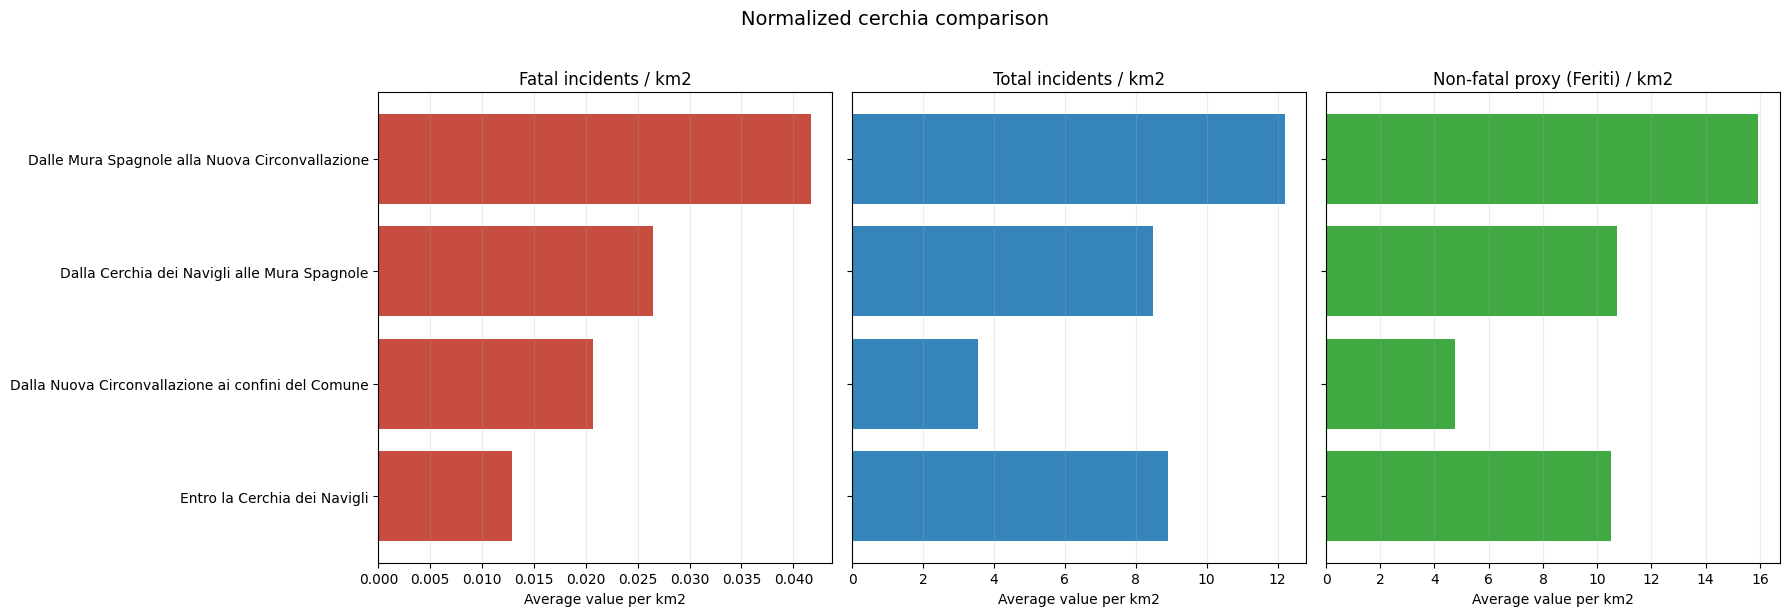

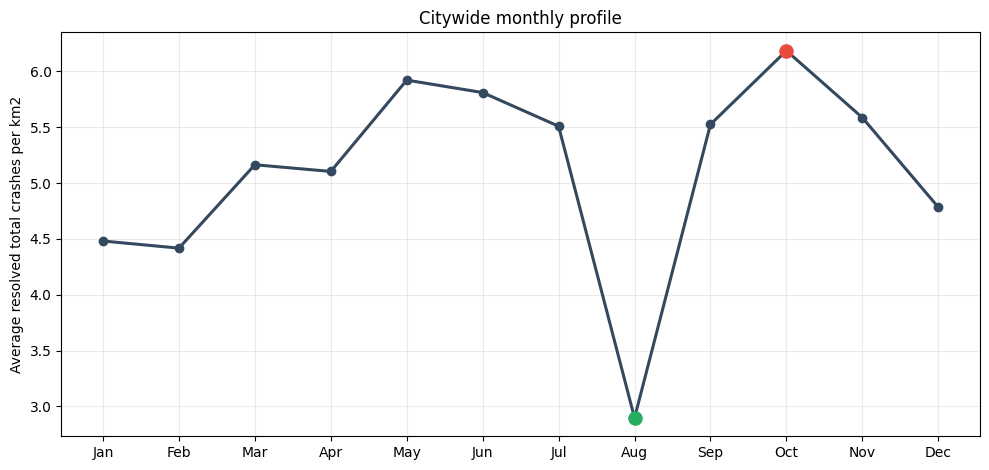

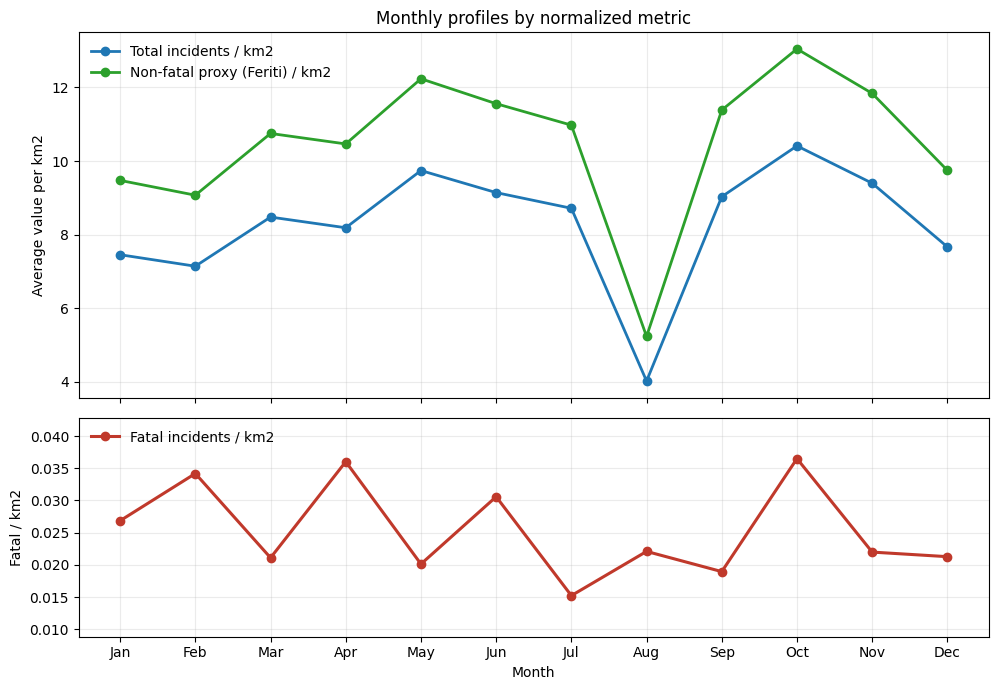

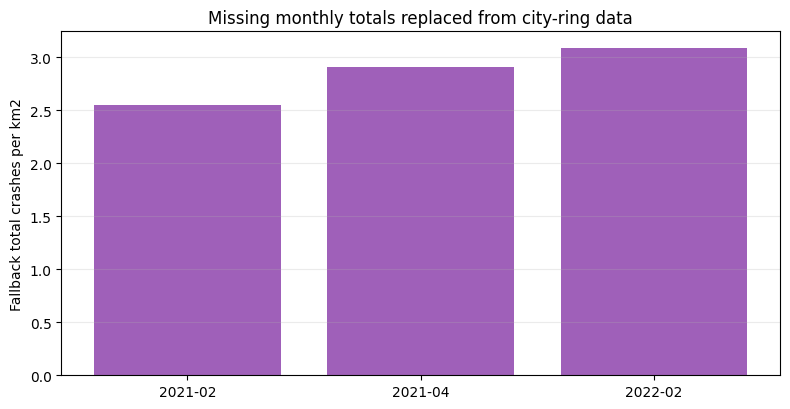

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

required_vars = [
    "ring_metrics_norm",
    "comparison",
    "month_labels",
    "mismatch_fallbacks",
    "known_total_area_km2",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(f"Run cell 3 first. Missing variables: {missing_vars}")

month_order = list(range(1, 13))
month_tick_labels = [month_labels[m] for m in month_order]

metric_specs = [
    ("fatal_incidents_per_km2", "Fatal incidents / km2", "#c0392b"),
    ("total_incidents_per_km2", "Total incidents / km2", "#1f77b4"),
    ("non_fatal_proxy_per_km2", "Non-fatal proxy (Feriti) / km2", "#2ca02c"),
]

cerchia_summary = (
    ring_metrics_norm.groupby("Cerchia", as_index=False)[[m[0] for m in metric_specs]]
    .mean()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for ax, (metric_col, metric_label, color) in zip(axes, metric_specs):
    chart_df = cerchia_summary.sort_values(metric_col, ascending=True)
    ax.barh(chart_df["Cerchia"], chart_df[metric_col], color=color, alpha=0.9)
    ax.set_title(metric_label)
    ax.set_xlabel("Average value per km2")
    ax.grid(axis="x", alpha=0.25)

fig.suptitle("Normalized cerchia comparison", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

city_month_trend = (
    comparison.groupby("month", as_index=False)["resolved_total_crashes_per_km2"]
    .mean()
    .set_index("month")
    .reindex(month_order)
    .reset_index()
)
city_month_trend["month_label"] = city_month_trend["month"].map(month_labels)

peak_idx = city_month_trend["resolved_total_crashes_per_km2"].idxmax()
low_idx = city_month_trend["resolved_total_crashes_per_km2"].idxmin()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    city_month_trend["month"],
    city_month_trend["resolved_total_crashes_per_km2"],
    marker="o",
    linewidth=2.2,
    color="#34495e",
)
ax.scatter(
    city_month_trend.loc[peak_idx, "month"],
    city_month_trend.loc[peak_idx, "resolved_total_crashes_per_km2"],
    s=90,
    color="#e74c3c",
    zorder=3,
)
ax.scatter(
    city_month_trend.loc[low_idx, "month"],
    city_month_trend.loc[low_idx, "resolved_total_crashes_per_km2"],
    s=90,
    color="#27ae60",
    zorder=3,
)
ax.set_xticks(month_order)
ax.set_xticklabels(month_tick_labels)
ax.set_ylabel("Average resolved total crashes per km2")
ax.set_title("Citywide monthly profile")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

monthly_metric_profiles = (
    ring_metrics_norm.groupby("month", as_index=False)[[m[0] for m in metric_specs]]
    .mean()
    .set_index("month")
    .reindex(month_order)
)

fig, (ax_main, ax_fatal) = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3.0, 1.8]},
)

for metric_col, metric_label, color in metric_specs:
    if metric_col == "fatal_incidents_per_km2":
        continue
    ax_main.plot(
        month_order,
        monthly_metric_profiles[metric_col],
        marker="o",
        linewidth=2,
        label=metric_label,
        color=color,
    )

fatal_series = monthly_metric_profiles["fatal_incidents_per_km2"]
fatal_range = float(fatal_series.max() - fatal_series.min())
fatal_pad = max(fatal_range * 0.30, 0.005)

ax_fatal.plot(
    month_order,
    fatal_series,
    marker="o",
    linewidth=2.2,
    label="Fatal incidents / km2",
    color="#c0392b",
)
ax_fatal.set_ylim(fatal_series.min() - fatal_pad, fatal_series.max() + fatal_pad)

ax_main.set_ylabel("Average value per km2")
ax_main.set_title("Monthly profiles by normalized metric")
ax_main.grid(alpha=0.25)
ax_main.legend(frameon=False, loc="upper left")

ax_fatal.set_ylabel("Fatal / km2")
ax_fatal.set_xlabel("Month")
ax_fatal.grid(alpha=0.25)
ax_fatal.legend(frameon=False, loc="upper left")
ax_fatal.set_xticks(month_order)
ax_fatal.set_xticklabels(month_tick_labels)

plt.tight_layout()
plt.show()

if not mismatch_fallbacks.empty:
    fallback_plot = mismatch_fallbacks.sort_values(["year", "month"]).copy()
    fallback_plot["year_month"] = (
        fallback_plot["year"].astype(int).astype(str)
        + "-"
        + fallback_plot["month"].astype(int).astype(str).str.zfill(2)
    )
    fallback_plot["fallback_per_km2"] = (
        fallback_plot["fallback_total_from_rings"] / known_total_area_km2
    )

    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.bar(
        fallback_plot["year_month"],
        fallback_plot["fallback_per_km2"],
        color="#8e44ad",
        alpha=0.85,
    )
    ax.set_ylabel("Fallback total crashes per km2")
    ax.set_title("Missing monthly totals replaced from city-ring data")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()